============================================================
# CELL 1: SETUP ENVIRONMENT
============================================================

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import os
import urllib.request

# Cek device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seed untuk reproduksibilitas
torch.manual_seed(42)
np.random.seed(42)

print("✅ Environment setup complete!")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
✅ Environment setup complete!
PyTorch version: 2.11.0+cpu


============================================================
# CELL 2: LOAD DATASET FASHION-MNIST
============================================================

📥 Downloading and preparing Fashion-MNIST dataset...


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 276kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.06MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.81MB/s]


✅ Fashion-MNIST Loaded!
   Training samples: 60000
   Testing samples: 10000

🖼️ Sample images from Fashion-MNIST:


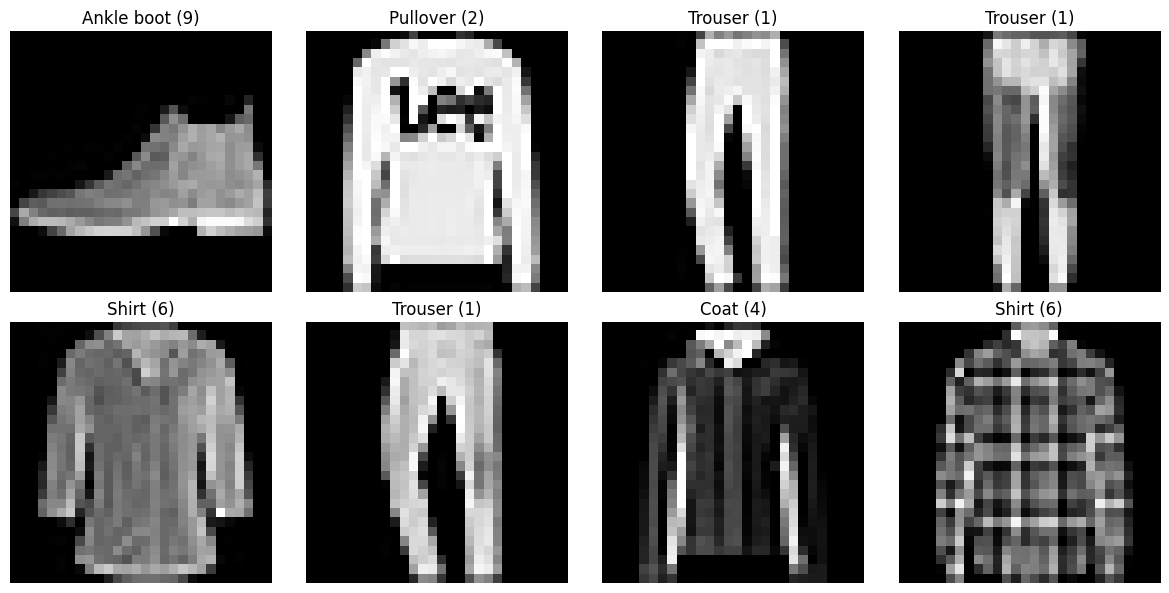


✅ DATASET PREPARATION COMPLETED!


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. DOWNLOAD & LOAD FASHION-MNIST DATASET
# ============================================================

print("📥 Downloading and preparing Fashion-MNIST dataset...")

def load_fashion_mnist(batch_size=128):
    # Transformasi standar: Convert ke tensor dan normalisasi
    # Fashion-MNIST adalah grayscale 28x28
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalisasi ke rentang [-1, 1]
    ])

    # Load training data
    train_dataset = datasets.FashionMNIST(
        root='./data_fashion',
        train=True,
        download=True,
        transform=transform
    )

    # Load testing data
    test_dataset = datasets.FashionMNIST(
        root='./data_fashion',
        train=False,
        download=True,
        transform=transform
    )

    # Buat DataLoader
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    return train_loader, test_loader, train_dataset, test_dataset

# Eksekusi Loading
train_loader, test_loader, train_dataset, test_dataset = load_fashion_mnist(batch_size=128)

# Map label ke nama kategori Fashion-MNIST
fashion_labels = {
    0: "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat",
    5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle boot"
}

print(f"\n✅ Fashion-MNIST Loaded!")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Testing samples: {len(test_dataset)}")

# ============================================================
# 2. VISUALISASI SAMPLE
# ============================================================

def show_samples(loader, num_samples=8):
    images, labels = next(iter(loader))
    plt.figure(figsize=(12, 6))
    for i in range(min(num_samples, len(images))):
        plt.subplot(2, 4, i+1)
        img = images[i].squeeze().numpy()
        img = (img + 1) / 2  # Denormalize ke [0,1]
        plt.imshow(img, cmap='gray')
        label_idx = labels[i].item()
        plt.title(f"{fashion_labels[label_idx]} ({label_idx})")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

print("\n🖼️ Sample images from Fashion-MNIST:")
show_samples(test_loader, num_samples=8)

print("\n✅ DATASET PREPARATION COMPLETED!")

============================================================
# CELL 3: CREATE LENET MODEL (ATAU TRAINING DARI AWAL)
============================================================

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
import time
import os
from google.colab import drive

# --- 1. Persiapan Path Drive ---
drive.mount('/content/drive')
model_dir = '/content/drive/MyDrive/model'
model_path = os.path.join(model_dir, 'final_lenet_fashion_mnist.pth')
os.makedirs(model_dir, exist_ok=True)

# --- 2. Load Dataset (Fashion-MNIST) ---
print("Menyiapkan dataset Fashion-MNIST...")
# Normalisasi umum untuk Fashion-MNIST: mean=0.5, std=0.5 (atau 0.2860, 0.3530)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data_fashion', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data_fashion', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# --- 3. Definisi Model LeNet-5 ---
class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = torch.relu(self.conv2(x))
        x = nn.functional.avg_pool2d(x, 2)
        x = x.view(-1, 16 * 5 * 5)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LeNet5().to(device)

# Variabel histori
training_history = {'loss': [], 'accuracy': []}

# --- 4. Cek Model di Drive ---
if os.path.exists(model_path):
    print(f"\n✅ Menemukan model di {model_path}. Memuat model dan histori...")
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])

    if 'history' in checkpoint:
        training_history = checkpoint['history']
        print(f"✅ Histori lengkap ditemukan ({len(training_history['accuracy'])} epoch):")
        for i, (acc, loss) in enumerate(zip(training_history['accuracy'], training_history['loss'])):
            print(f"   Epoch {i+1}: Accuracy = {acc:.2f}%, Loss = {loss:.4f}")
    else:
        print("⚠️ Model dimuat tetapi data histori per epoch tidak ditemukan.")

    print("\nModel berhasil dimuat. Melewati proses training.")
else:
    print("\n❌ Model tidak ditemukan di Drive. Memulai training dari awal untuk Fashion-MNIST...")

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 10  # Fashion-MNIST biasanya butuh epoch lebih banyak dari MNIST

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for batch_idx, (data, target) in pbar:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        # Evaluasi
        model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                outputs = model(data)
                _, predicted = torch.max(outputs.data, 1)
                correct += (predicted == target).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / len(test_dataset)

        training_history['loss'].append(epoch_loss)
        training_history['accuracy'].append(epoch_acc)

        print(f'\nEpoch {epoch+1} selesai. Avg Loss: {epoch_loss:.4f}, Test Akurasi: {epoch_acc:.2f}%')

    # Simpan ke Drive
    print(f"\n💾 Menyimpan model dan histori lengkap ke {model_path}...")
    torch.save({
        'model_state_dict': model.state_dict(),
        'history': training_history
    }, model_path)
    print("✅ Model dan histori berhasil disimpan!")

# Final Summary
if training_history['accuracy']:
    print(f"\n--- Ringkasan Training Fashion-MNIST ---")
    print(f"Total Epoch: {len(training_history['accuracy'])}")
    print(f"Final Accuracy: {training_history['accuracy'][-1]:.2f}%")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Menyiapkan dataset Fashion-MNIST...

❌ Model tidak ditemukan di Drive. Memulai training dari awal untuk Fashion-MNIST...


Epoch [1/10]: 100%|██████████| 938/938 [00:38<00:00, 24.19it/s, loss=0.3469]



Epoch 1 selesai. Avg Loss: 0.6515, Test Akurasi: 82.48%


Epoch [2/10]: 100%|██████████| 938/938 [00:36<00:00, 25.96it/s, loss=0.2806]



Epoch 2 selesai. Avg Loss: 0.4198, Test Akurasi: 85.74%


...


Epoch 8 selesai. Avg Loss: 0.2678, Test Akurasi: 88.15%


Epoch [9/10]: 100%|██████████| 938/938 [00:35<00:00, 26.41it/s, loss=0.1819]



Epoch 9 selesai. Avg Loss: 0.2547, Test Akurasi: 88.68%


Epoch [10/10]: 100%|██████████| 938/938 [00:36<00:00, 25.49it/s, loss=0.1976]



Epoch 10 selesai. Avg Loss: 0.2432, Test Akurasi: 88.71%

💾 Menyimpan model dan histori lengkap ke /content/drive/MyDrive/model/final_lenet_fashion_mnist.pth...
✅ Model dan histori berhasil disimpan!

--- Ringkasan Training Fashion-MNIST ---
Total Epoch: 10
Final Accuracy: 88.71%


============================================================
# CELL 4: IMPLEMENTASI FGQ TERNARY QUANTIZATION
============================================================

## Fine-Grained Quantization Ternary

In [8]:
def ternary_quantize_group(weight_tensor, group_size=4):
    """
    Melakukan ternary quantization per group (FGQ)

    Args:
        weight_tensor: Tensor bobot
        group_size (N): Jumlah bobot per kelompok

    Returns:
        ternary_weights: Bobot ternary {-alpha, 0, +alpha}
        alphas: Faktor skala per kelompok
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    n = flat_weights.numel()

    ternary_flat = torch.zeros_like(flat_weights)
    alphas = []

    for i in range(0, n, group_size):
        group = flat_weights[i:min(i+group_size, n)]
        group_size_actual = len(group)

        if group_size_actual == 0:
            continue

        abs_group = torch.abs(group)

        # Jika semua bobot 0
        if abs_group.max().item() == 0:
            alphas.append(0.0)
            continue

        # Cari threshold optimal (20 kandidat)
        thresholds = torch.linspace(
            abs_group.min().item(),
            abs_group.max().item(),
            steps=20
        )

        best_delta = 0
        best_score = -float('inf')

        for delta in thresholds:
            mask = abs_group > delta
            if mask.sum() == 0:
                continue
            sum_abs = abs_group[mask].sum()
            count = mask.sum().float()
            score = (sum_abs ** 2) / count
            if score > best_score:
                best_score = score
                best_delta = delta

        # Hitung alpha
        mask = abs_group > best_delta
        if mask.sum() == 0:
            alphas.append(0.0)
            continue

        alpha = abs_group[mask].sum() / mask.sum().float()
        alphas.append(alpha.item())

        # Buat ternary weights
        ternary_group = torch.zeros_like(group)
        ternary_group[group > best_delta] = alpha
        ternary_group[group < -best_delta] = -alpha

        ternary_flat[i:min(i+group_size, n)] = ternary_group

    return ternary_flat.reshape(original_shape), alphas

def apply_fgq_to_model(model, group_size=4, verbose=True):
    """
    Menerapkan FGQ ke semua layer konvolusi dan linear
    """
    print(f"\n🔧 Applying FGQ with N={group_size}...")
    alpha_means = []
    layer_names = []
    total_params = 0

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            original_weight = module.weight.data
            total_params += original_weight.numel()

            ternary_weight, alphas = ternary_quantize_group(
                original_weight,
                group_size=group_size
            )
            module.weight.data = ternary_weight

            alpha_mean = np.mean(alphas) if alphas else 0
            alpha_means.append(alpha_mean)
            layer_names.append(name)

            if verbose:
                num_groups = original_weight.numel() // group_size if group_size > 0 else 0
                print(f"  ✓ {name}: {original_weight.shape}, "
                      f"groups={num_groups}, α_mean={alpha_mean:.4f}")

    print(f"   Total parameters quantized: {total_params:,}")
    return model, alpha_means, layer_names

print("\n" + "="*50)
print("CELL 5: FGQ IMPLEMENTATION READY")
print("="*50)

print("✅ FGQ functions defined!")
print("   - ternary_quantize_group(): quantize per group")
print("   - apply_fgq_to_model(): apply to entire model")


CELL 5: FGQ IMPLEMENTATION READY
✅ FGQ functions defined!
   - ternary_quantize_group(): quantize per group
   - apply_fgq_to_model(): apply to entire model


## Standard Quantization Ternary

In [9]:
def standard_ternary_quantize(weight_tensor):
    """
    Melakukan standard ternary quantization pada seluruh tensor bobot
    (Global quantization, bukan per group/fine-grained)
    """
    original_shape = weight_tensor.shape
    flat_weights = weight_tensor.flatten()
    abs_weights = torch.abs(flat_weights)

    # Jika semua bobot 0
    if abs_weights.max().item() == 0:
        return torch.zeros_like(weight_tensor), 0.0

    # Mencari threshold optimal secara global (berdasarkan rata-rata absolut)
    # Metode umum: delta = 0.7 * E[|W|]
    delta = 0.7 * torch.mean(abs_weights)

    # Hitung mask untuk nilai yang lebih besar dari threshold
    mask = abs_weights > delta

    if mask.sum() == 0:
        return torch.zeros_like(weight_tensor), 0.0

    # Hitung alpha (skala) global
    alpha = abs_weights[mask].sum() / mask.sum().float()

    # Buat ternary weights
    ternary_flat = torch.zeros_like(flat_weights)
    ternary_flat[flat_weights > delta] = alpha
    ternary_flat[flat_weights < -delta] = -alpha

    return ternary_flat.reshape(original_shape), alpha.item()

def apply_standard_ternary_to_model(model, verbose=True):
    """
    Menerapkan Standard Ternary Quantization ke semua layer konvolusi dan linear
    """
    print(f"\n🔧 Applying Standard Ternary Quantization (Global)...")
    layer_alphas = []

    for name, module in model.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            original_weight = module.weight.data

            ternary_weight, alpha = standard_ternary_quantize(original_weight)
            module.weight.data = ternary_weight

            layer_alphas.append(alpha)

            if verbose:
                print(f"  ✓ {name}: {original_weight.shape}, α={alpha:.4f}")

    return model, layer_alphas

print("\n" + "="*50)
print("CELL 5.1: STANDARD TERNARY QUANTIZATION READY")
print("="*50)
print("✅ Standard Ternary functions defined!")


CELL 5.1: STANDARD TERNARY QUANTIZATION READY
✅ Standard Ternary functions defined!


============================================================
# CELL 5: SKENARIO A - DENGAN FINE-GRAINED QUANTIZATION ============================================================

   Mengambil Baseline Accuracy dari model LeNet-5 Fashion-MNIST...

CELL 6: SKENARIO A - TANPA FINE-TUNING (Fashion-MNIST)

   Baseline accuracy (FP32): 88.71%

Testing N = 2

🔧 Applying FGQ with N=2...
  ✓ conv1: torch.Size([6, 1, 5, 5]), groups=75, α_mean=0.2719
  ✓ conv2: torch.Size([16, 6, 5, 5]), groups=1200, α_mean=0.1533
  ✓ fc1: torch.Size([120, 400]), groups=24000, α_mean=0.1035
  ✓ fc2: torch.Size([84, 120]), groups=5040, α_mean=0.1158
  ✓ fc3: torch.Size([10, 84]), groups=420, α_mean=0.2065
   Total parameters quantized: 61,470

   Evaluating FGQ model...

✅ FGQ N=2 Top-1 Accuracy: 77.18%
   Drop from baseline: 11.53%

Testing N = 4

🔧 Applying FGQ with N=4...
  ✓ conv1: torch.Size([6, 1, 5, 5]), groups=37, α_mean=0.2830
  ✓ conv2: torch.Size([16, 6, 5, 5]), groups=600, α_mean=0.1634
  ✓ fc1: torch.Size([120, 400]), groups=12000, α_mean=0.1141
  ✓ fc2: torch.Size([84, 120]), groups=2520, α_mean=0.1290
  ✓ fc3: torch.Size([10, 84]), groups=210, α_mean=0.2390
   Total paramete

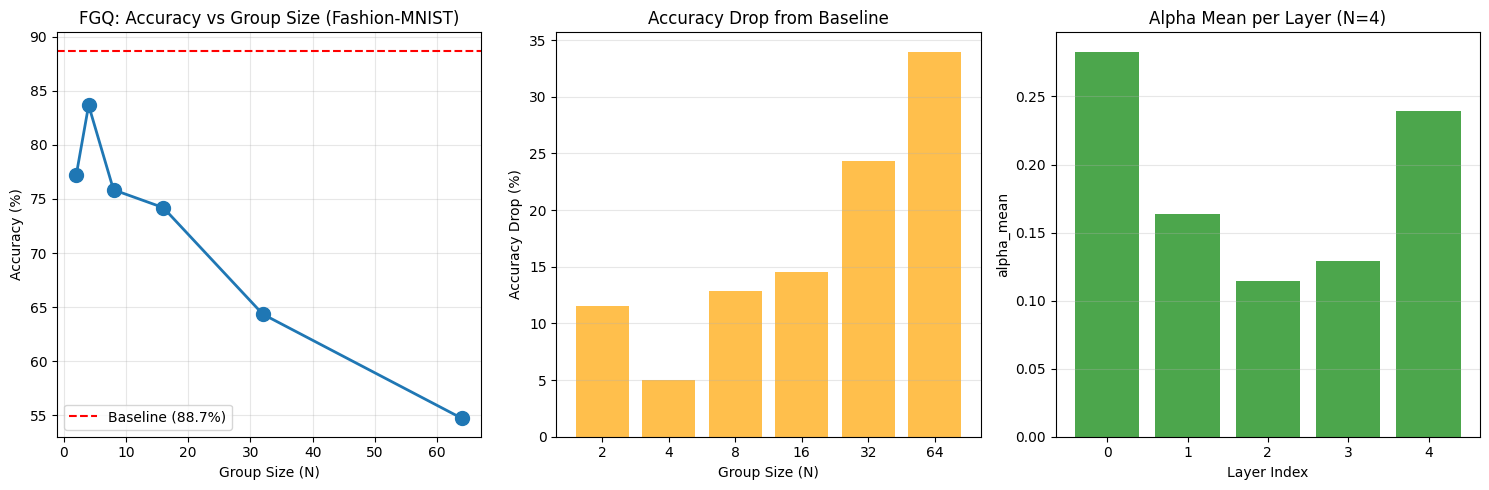

In [10]:
# --- Persiapan Baseline Fashion-MNIST ---
print("   Mengambil Baseline Accuracy dari model LeNet-5 Fashion-MNIST...")
baseline_acc = evaluate_accuracy(model, test_loader)

import copy
baseline_state = copy.deepcopy(model.state_dict())

print("\n" + "="*50)
print("CELL 6: SKENARIO A - TANPA FINE-TUNING (Fashion-MNIST)")
print("="*50)

print(f"\n   Baseline accuracy (FP32): {baseline_acc:.2f}%")

group_sizes = [2, 4, 8, 16, 32, 64]
results = {'N': [], 'accuracy': [], 'drop': [], 'alpha_means': []}

for N in group_sizes:
    print(f"\n{'='*40}")
    print(f"Testing N = {N}")
    print(f"{'='*40}")

    test_model = LeNet5().to(device)
    test_model.load_state_dict(baseline_state)
    test_model.eval()

    test_model, alpha_means, layer_names = apply_fgq_to_model(test_model, group_size=N, verbose=True)

    print("\n   Evaluating FGQ model...")
    acc = evaluate_accuracy(test_model, test_loader)
    drop = baseline_acc - acc

    print(f"\n✅ FGQ N={N} Top-1 Accuracy: {acc:.2f}%")
    print(f"   Drop from baseline: {drop:.2f}%")

    results['N'].append(N)
    results['accuracy'].append(acc)
    results['drop'].append(drop)
    results['alpha_means'].append(alpha_means)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(results['N'], results['accuracy'], marker='o', linewidth=2, markersize=10)
plt.axhline(y=baseline_acc, color='r', linestyle='--', label=f'Baseline ({baseline_acc:.1f}%)')
plt.xlabel('Group Size (N)')
plt.ylabel('Accuracy (%)')
plt.title('FGQ: Accuracy vs Group Size (Fashion-MNIST)')
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 2)
plt.bar([str(n) for n in results['N']], results['drop'], color='orange', alpha=0.7)
plt.xlabel('Group Size (N)')
plt.ylabel('Accuracy Drop (%)')
plt.title('Accuracy Drop from Baseline')
plt.grid(True, alpha=0.3, axis='y')

plt.subplot(1, 3, 3)
if len(results['alpha_means']) > 1:
    alpha_means_4 = results['alpha_means'][1]
    plt.bar(range(len(alpha_means_4)), alpha_means_4, alpha=0.7, color='green')
    plt.xlabel('Layer Index')
    plt.ylabel('alpha_mean')
    plt.title(f'Alpha Mean per Layer (N=4)')
    plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

============================================================
# CELL 6: SKENARIO B - DENGAN STANDARD QUANTIZATION
============================================================


CELL 7: SKENARIO C - STANDARD TERNARY (Fashion-MNIST)
   Baseline accuracy (FP32): 88.71%

🔧 Applying Standard Ternary Quantization (Global)...
  ✓ conv1: torch.Size([6, 1, 5, 5]), α=0.2722
  ✓ conv2: torch.Size([16, 6, 5, 5]), α=0.1714
  ✓ fc1: torch.Size([120, 400]), α=0.1211
  ✓ fc2: torch.Size([84, 120]), α=0.1240
  ✓ fc3: torch.Size([10, 84]), α=0.2218

   Evaluating Standard Ternary model...

✅ Standard Ternary Top-1 Accuracy: 79.54%
   Drop from baseline: 9.17%


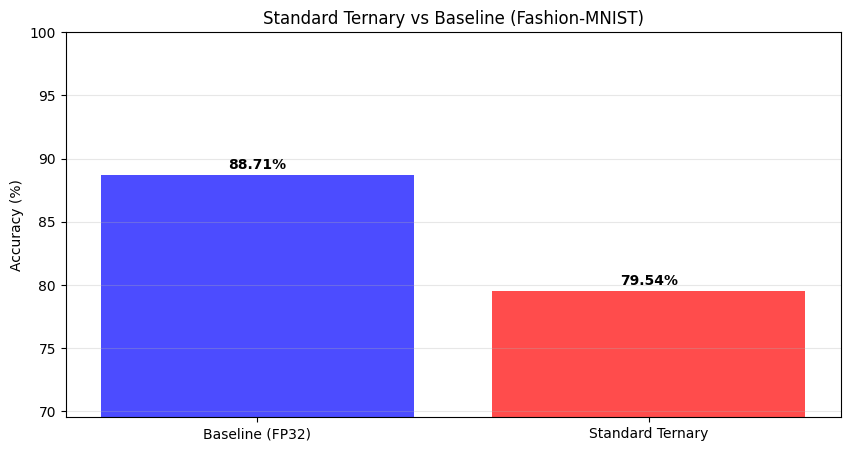

In [11]:
print("\n" + "="*50)
print("CELL 7: SKENARIO C - STANDARD TERNARY (Fashion-MNIST)")
print("="*50)

print(f"   Baseline accuracy (FP32): {baseline_acc:.2f}%")

model_st = LeNet5().to(device)
model_st.load_state_dict(baseline_state)
model_st.eval()

model_st, layer_alphas = apply_standard_ternary_to_model(model_st, verbose=True)

print("\n   Evaluating Standard Ternary model...")
acc_st = evaluate_accuracy(model_st, test_loader)
drop_st = baseline_acc - acc_st

print(f"\n✅ Standard Ternary Top-1 Accuracy: {acc_st:.2f}%")
print(f"   Drop from baseline: {drop_st:.2f}%")

plt.figure(figsize=(10, 5))
labels = ['Baseline (FP32)', 'Standard Ternary']
accuracies = [baseline_acc, acc_st]
plt.bar(labels, accuracies, color=['blue', 'red'], alpha=0.7)
plt.ylabel('Accuracy (%)')
plt.title('Standard Ternary vs Baseline (Fashion-MNIST)')
plt.ylim(max(0, min(accuracies) - 10), 100)
plt.grid(True, axis='y', alpha=0.3)
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.5, f"{acc:.2f}%", ha='center', fontweight='bold')
plt.show()

============================================================
# CELL 7: PERBANDINGAN SKENARIO A vs B
============================================================


CELL 8: PERBANDINGAN AKURASI AKHIR (Fashion-MNIST)


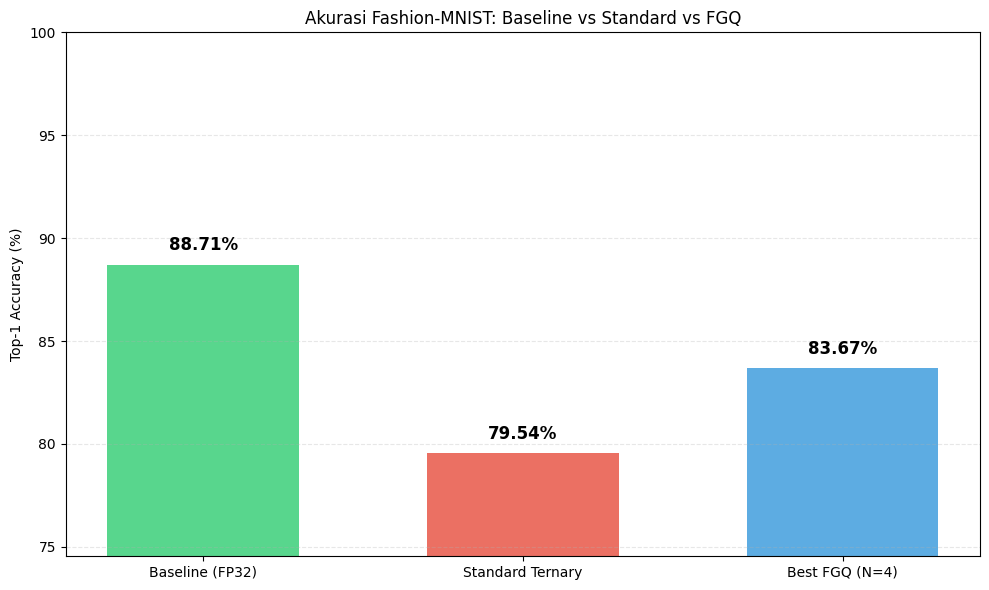


1. Akurasi Baseline (FP32)  : 88.71%
2. Akurasi Standard Ternary : 79.54% (Drop: 9.17%) 
3. Akurasi Terbaik FGQ (N=4): 83.67% (Drop: 5.04%)


In [12]:
print("\n" + "="*50)
print("CELL 8: PERBANDINGAN AKURASI AKHIR (Fashion-MNIST)")
print("="*50)

best_fgq_acc = max(results['accuracy'])
best_n = results['N'][results['accuracy'].index(best_fgq_acc)]

labels = ['Baseline (FP32)', 'Standard Ternary', f'Best FGQ (N={best_n})']
values = [baseline_acc, acc_st, best_fgq_acc]
colors = ['#2ecc71', '#e74c3c', '#3498db']

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors, alpha=0.8, width=0.6)
plt.ylabel('Top-1 Accuracy (%)')
plt.title('Akurasi Fashion-MNIST: Baseline vs Standard vs FGQ')
plt.ylim(max(0, min(values) - 5), 100)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5, f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n1. Akurasi Baseline (FP32)  : {baseline_acc:.2f}%")
print(f"2. Akurasi Standard Ternary : {acc_st:.2f}% (Drop: {baseline_acc - acc_st:.2f}%) ")
print(f"3. Akurasi Terbaik FGQ (N={best_n}): {best_fgq_acc:.2f}% (Drop: {baseline_acc - best_fgq_acc:.2f}%)")